In [11]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pandas as pd
import numpy as np
import time
import gc

In [2]:
# Evaluation -- Random Forest

# df = pd.read_csv('../../data/joined/augmented_properties_with_distances.csv', nrows=100_000 low_memory=False)
# df = pd.read_csv('../../data/joined/augmented_properties_with_distances.csv', nrows=1_000_000, low_memory=False)
df = pd.read_csv('../../data/joined/augmented_properties_with_distances.csv',  low_memory=False)
df['log_fullval'] = np.log(df['FULLVAL'] + 1)

# New features
df['log_dist_bus'] = np.log(df['dist_to_bus_m'] + 1)  # + 1 avoids log(0)
df['log_dist_subway'] = np.log(df['dist_to_subway_m'] + 1)
df['num_subway_routes'] = df['nearest_subway_routes'].str.split(',').str.len().fillna(0)  # Count routes

# Select expanded X - drop any NaNs after deriving
X = df[['log_dist_bus', 'log_dist_subway', 'TAXCLASS', 'num_subway_routes', 'NTA']].copy()
y = df['log_fullval']

# Handle categories: One hot NTA (top 20 for simplicity --- full would use all)
top_ntas = X['NTA'].value_counts().head(20).index
X['NTA'] = X['NTA'].apply(lambda x: x if x in top_ntas else 'Other')

# Drop NaNs
mask = ~(X.isna().any(axis=1)) & y.notna()
X_clean = X[mask]
y_clean = y[mask]
print(f"Shape after dropping NaNs: {X_clean.shape} (dropped {len(X) - len(X_clean)} rows)")

# Pipeline for preprocessing 
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(drop='first', sparse_output=False), ['NTA'])], remainder='passthrough')

# Split and fit pipeline with Random Forest
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size = 0.2, random_state=42)
model = Pipeline([('preproc', preprocessor),('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
model.fit(X_train, y_train)

# Predict and score
y_pred = model.predict(X_test)
print(f"R-squared score on test set: {r2_score(y_test, y_pred):.4f}")

# Feature importances - see if we can extract any insights
importances = model.named_steps['rf'].feature_importances_

 # Skip first for drop
feature_names = (['NTA_' + name for name in top_ntas[1:]] + ['log_dist_bus', 'log_dist_subway', 'TAXCLASS', 'num_subway_routes'])
print("Top feature importances:", sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)[:5])

Shape after dropping NaNs: (8526298, 5) (dropped 866554 rows)
R-squared score on test set: 0.9164
Top feature importances: [('TAXCLASS', np.float64(0.3789441288957847)), ('log_dist_subway', np.float64(0.32004861946891083)), ('num_subway_routes', np.float64(0.16000272299877683)), ('NTA_Bayside-Bayside Hills', np.float64(0.04231140180400222)), ('NTA_Queens Village', np.float64(0.009973565652786238))]


In [16]:
# START XGBOOST

# Split 
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)


xgb_regressor = xgb.XGBRegressor(
    n_estimators = 1000,       
    learning_rate = 0.05,    
    max_depth = 10,           
    subsample = 0.8,           
    colsample_bytree = 0.8,    
    random_state = 42,
    n_jobs = -1,
    tree_method = 'hist'       # Speed optimization
)

model_xgb = Pipeline([
    ('preproc', preprocessor),
    ('xgb', xgb_regressor)
])

model_xgb.fit(X_train, y_train)

# Predict and score
y_pred_xgb = model_xgb.predict(X_test)
print(f"XGBoost R-squared score on test set: {r2_score(y_test, y_pred_xgb):.4f}")

# Feature importances
importances_xgb = model_xgb.named_steps['xgb'].feature_importances_

#  Skip first for drop
feature_names = (['NTA_' + name for name in top_ntas[1:]] + ['log_dist_bus', 'log_dist_subway', 'TAXCLASS', 'num_subway_routes'])
print("Top XGBoost feature importances:", sorted(zip(feature_names, importances_xgb), key=lambda x: x[1], reverse=True)[:5])

XGBoost R-squared score on test set: 0.6113
Top XGBoost feature importances: [('NTA_Bayside-Bayside Hills', np.float32(0.58816266)), ('num_subway_routes', np.float32(0.054769825)), ('NTA_Georgetown-Marine Park-Bergen Beach-Mill Basin', np.float32(0.043560576)), ('NTA_Queens Village', np.float32(0.038828578)), ('NTA_Bensonhurst West', np.float32(0.034292787))]


In [ ]:
# START XGBOOST - Tuned

# Reuse split, pipeline, and preprocessor
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
base_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('xgb', xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'))
])

# Param grid 
param_grid = {
    'xgb__n_estimators': [800, 1000, 1500, 2000], 
    'xgb__learning_rate': [0.01, 0.03, 0.05],    
    'xgb__max_depth': [8, 10, 12],              
    'xgb__subsample': [0.7, 0.8, 0.9],            # prevent overfitting
    'xgb__colsample_bytree': [0.7, 0.8, 0.9],      # prevent overfitting
}

# Grid search on the full pipeline
grid_search = RandomizedSearchCV(base_pipeline, param_grid, n_iter=5, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best model and score
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Base XGBoost R-squared: {r2_score(y_test, model_xgb.predict(X_test)):.4f}")  # From prior run
print(f"Tuned XGBoost R-squared: {r2_tuned:.4f}")
print(f"Best params: {grid_search.best_params_}")

# Updated importances with tuned model
importances_tuned = best_model.named_steps['xgb'].feature_importances_

n_dummies = len(top_ntas) - 1  # 19 if 20 top NTAs
nta_names = ['NTA_' + name for name in top_ntas[1:]]
numeric_names = ['log_dist_bus', 'log_dist_subway', 'TAXCLASS', 'num_subway_routes']
feature_names_tuned = nta_names + numeric_names  # Matches preproc output
print("Top tuned XGBoost importances:", sorted(zip(feature_names_tuned, importances_tuned), key=lambda x: x[1], reverse=True)[:5])

Fitting 3 folds for each of 5 candidates, totalling 15 fits


Python(60010) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(60011) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(60012) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(60013) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(60014) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(60015) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(60016) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(60017) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Base XGBoost R-squared: 0.6113
Tuned XGBoost R-squared: 0.6282
Best params: {'xgb__subsample': 0.7, 'xgb__n_estimators': 800, 'xgb__max_depth': 12, 'xgb__learning_rate': 0.03, 'xgb__colsample_bytree': 0.8}
Top tuned XGBoost importances: [('NTA_Parkchester', np.float32(0.6517834)), ('TAXCLASS', np.float32(0.066145256)), ('NTA_Flushing', np.float32(0.039902374)), ('NTA_Lincoln Square', np.float32(0.02945009)), ('NTA_Park Slope-Gowanus', np.float32(0.025984688))]


In [10]:
# 5-fold CV on RandomForest with progress logging

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []
fold = 1

print(f"Starting 5-Fold CV on {len(X_clean)} rows...")

# Manual loop
for train_index, test_index in kf.split(X_clean):
    start_time = time.time()
    
    # Split data
    X_train_fold, X_test_fold = X_clean.iloc[train_index], X_clean.iloc[test_index]
    y_train_fold, y_test_fold = y_clean.iloc[train_index], y_clean.iloc[test_index]
    
    # Fit model and append score
    model.fit(X_train_fold, y_train_fold)
    score = model.score(X_test_fold, y_test_fold)
    scores.append(score)
    
    elapsed = (time.time() - start_time) / 60
    print(f"Fold {fold}/5 Completed: R2 = {score:.4f}  (Time: {elapsed:.1f} mins)")
    
    # Clear memory before next MASSIVE fold
    del X_train_fold, X_test_fold, y_train_fold, y_test_fold
    gc.collect()
    
    fold += 1

print(f"\nFinal Mean CV R-squared: {np.mean(scores):.4f} (+/- {np.std(scores) * 2:.4f})")

Starting 5-Fold CV on 8526298 rows...
Fold 1/5 Completed: R2 = 0.9164  (Time: 10.1 mins)
Fold 2/5 Completed: R2 = 0.9152  (Time: 10.0 mins)
Fold 3/5 Completed: R2 = 0.9165  (Time: 9.9 mins)
Fold 4/5 Completed: R2 = 0.9162  (Time: 10.0 mins)
Fold 5/5 Completed: R2 = 0.9162  (Time: 9.8 mins)

Final Mean CV R-squared: 0.9161 (+/- 0.0009)


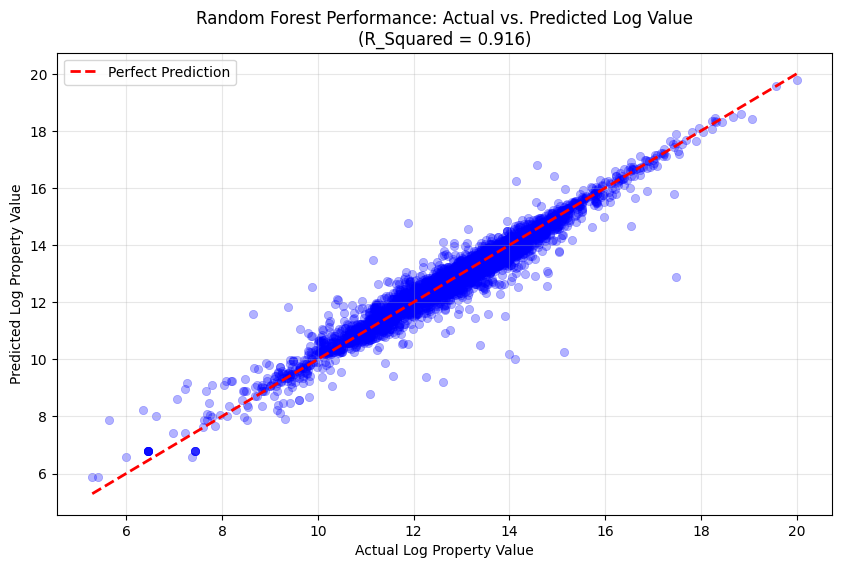

In [15]:
# Plots

# Sample data for plotting, ~10k points is enough to see the trend
sample_indices = np.random.choice(len(y_test), size=10_000, replace=False)
y_test_sample = y_test.iloc[sample_indices]
y_pred_sample = model.predict(X_test.iloc[sample_indices])

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_sample, y=y_pred_sample, alpha=0.3, edgecolor=None, color='blue')

# Add a "perfect prediction line 
min_val = min(y_test_sample.min(), y_pred_sample.min())
max_val = max(y_test_sample.max(), y_pred_sample.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title(f"Random Forest Performance: Actual vs. Predicted Log Value\n(R_Squared = {r2_score(y_test, y_pred):.3f})")
plt.xlabel("Actual Log Property Value")
plt.ylabel("Predicted Log Property Value")
plt.legend()
plt.grid(True, alpha=0.3)

# Save for your report
plt.savefig("../../figures/rf_actual_vs_predicted.png", dpi=300)
plt.show()